# 0. Import library

In [98]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


cuda is available


# 1-1. Import Data 

In [99]:
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')
print(df_all.shape)
print(df_all.columns)

nan_rows = df_all[df_all.isna().any(axis=1)]

df_all = df_all.dropna()

loc_X = df_all["X"].to_numpy().reshape(-1,1)
loc_Y = df_all["Y"].to_numpy().reshape(-1,1)
loc_Z = df_all["Z"].to_numpy().reshape(-1,1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
# dist_Z = df_all["Dist_to_nearest_Z"].to_numpy()[::2].reshape(-1,1)
scan_spd = df_all["scanning_speed"].to_numpy().reshape(-1,1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1,1)
laser_on_off = df_all["laser_power_number"].to_numpy().reshape(-1,1)

# apply moving average for mp temp
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1,1)

# apply moving average for mp depth
mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw,4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1,1)       


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


## 1-2. Normalize data

In [100]:
# stack input array
x_original_scale = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)
y_original_scale = np.concatenate((mp_temp, mp_depth), axis=1)

# scaling
x_max = np.max(x_original_scale,0).reshape(1,-1)
x_min = np.min(x_original_scale,0).reshape(1,-1) 
y_max = np.max(y_original_scale,0).reshape(1,-1) 
y_min = np.min(y_original_scale,0).reshape(1,-1)

print("x_max:", np.round(x_max, 3).tolist())
print("x_min:", np.round(x_min, 3).tolist())
print("y_max:", np.round(y_max, 3).tolist())
print("y_min:", np.round(y_min, 3).tolist())

x_max: [[7.5, 20.0, 20.0, 732.298]]
x_min: [[0.0, 0.75, 0.75, 504.26]]
y_max: [[4509.855, 0.551]]
y_min: [[436.608, -0.559]]


In [101]:
class scalers():
    def __init__(self,x_max, x_min, y_max, y_min) -> None:
        self.x_max = x_max
        self.x_min = x_min
        self.y_max = y_max
        self.y_min = y_min
        
        return None
    
    def scaler_x(self, x_original, dim_id = -1):
        if dim_id == -1:
            x_s = -1 + 2 * ((x_original - self.x_min) / (self.x_max-self.x_min))
            return x_s
        else: 
            x_s = -1 + 2 * (x_original - self.x_min[0,dim_id]) / (self.x_max[0,dim_id] - self.x_min[0,dim_id])
            return x_s
    
    def inv_scaler_x(self, x_s, dim_id = -1):
        
        if dim_id == -1:
            x_original = (x_s + 1)*0.5*(self.x_max-self.x_min) + self.x_min
            return x_original
        else: 
            x_original = (x_s + 1)*0.5*(self.x_max[0,dim_id] - self.x_min[0,dim_id]) + self.x_min[0,dim_id]
            return x_original
        
    def scaler_y(self, y_original):
        return -1 + 2 * ((y_original - self.y_min) / (self.y_max-self.y_min))
    
    def inv_scaler_y(self, y_s):
        return (y_s + 1)*0.5*(self.y_max-self.y_min) + self.y_min

In [102]:
scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original_scale)
y_s = scaler.scaler_y(y_original_scale)

print("x_s range:", np.min(x_s), "to", np.max(x_s))
print("y_s range:", np.min(y_s), "to", np.max(y_s))

print("x_s shape:", x_s.shape)
print("y_s shape:", y_s.shape)

x_s range: -1.0 to 1.0
y_s range: -1.0 to 1.0
x_s shape: (610417, 4)
y_s shape: (610417, 2)


## 1-3. Generate data

In [103]:
length = y_s.shape[0]

y_s_ref = np.random.uniform(0.0, 1.0, size=(length, 1))

e = 0.0001
y_depth_low = np.random.uniform(0.1423-e, 0.1423+e, size = (length,1))
y_depth_up = np.random.uniform(0.4126-e, 0.4126+e, size = (length,1))
# constraints!
#y_depth_low = 0*np.random.uniform(0.0, 0.5, size=(length, 1))
#y_depth_up = 0*np.random.uniform(0.5, 1.0, size=(length, 1))

y_s_const = np.concatenate((y_depth_low, y_depth_up), axis=1)

print("y_s_ref shape:", y_s_ref.shape)
print("y_s_const shape:", y_s_const.shape)

y_s_ref shape: (610417, 1)
y_s_const shape: (610417, 2)


## 1-4. Split data

In [104]:
import numpy as np
import pandas as pd
import torch
import copy
from tqdm import tqdm

# =====================================================
# 1. Load & preprocess raw data
# =====================================================
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')

print(df_all.shape)
print(df_all.columns)

# ---- global time index (핵심) ----
df_all = df_all.reset_index(drop=True)
df_all["time_id"] = np.arange(len(df_all))

# ---- NaN handling (time_id 유지) ----
nan_rows = df_all[df_all.isna().any(axis=1)]
df_all = df_all.dropna().reset_index(drop=True)

# =====================================================
# 2. Feature extraction
# =====================================================
loc_Z = df_all["Z"].to_numpy().reshape(-1, 1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1, 1)

# ---- global time id ----
time_id_all = df_all["time_id"].to_numpy()

# =====================================================
# 3. Melt pool smoothing
# =====================================================
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw, 4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1, 1)

mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw, 4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1, 1)

# =====================================================
# 4. Stack original-scale arrays
# =====================================================
x_original = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)  # (N,4)
y_original = np.concatenate((mp_temp, mp_depth), axis=1)                  # (N,2)

# =====================================================
# 5. Scaling (-1 ~ 1)
# =====================================================
x_max = np.max(x_original, axis=0, keepdims=True)
x_min = np.min(x_original, axis=0, keepdims=True)
y_max = np.max(y_original, axis=0, keepdims=True)
y_min = np.min(y_original, axis=0, keepdims=True)

scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original)
y_s = scaler.scaler_y(y_original)

# =====================================================
# 6. Reference / Constraint (global arrays)
# =====================================================
length = y_s.shape[0]

# =====================================================
# Global reference (temperature)
# =====================================================
y_ref_global = y_s[:, 0:1]   # (N, 1)


# depth constraint (global)
e = 1e-4
y_depth_low = np.random.uniform(0.1423 - e, 0.1423 + e, size=(length, 1))
y_depth_up  = np.random.uniform(0.4126 - e, 0.4126 + e, size=(length, 1))
y_const_global = np.concatenate((y_depth_low, y_depth_up), axis=1)  # (N,2)

# =====================================================
# 7. Train / Validation split (time-consistent)
# =====================================================
cutoff_index = int(np.round(0.8 * length))

x_train, y_train = x_s[:cutoff_index], y_s[:cutoff_index]
x_val,   y_val   = x_s[cutoff_index:], y_s[cutoff_index:]

time_id_train = time_id_all[:cutoff_index]
time_id_val   = time_id_all[cutoff_index:]

# =====================================================
# 8. Sliding window construction (WITH time index)
# =====================================================
window = 50
P = 50

# ------------------ Training set ------------------
n_train = cutoff_index - window - P

x_past_train = np.empty((n_train, window, 4))
y_past_train = np.empty((n_train, window, 2))
x_future_train = np.empty((n_train, P, 3))
y_ref_train_seq = np.empty((n_train, P, 1))
y_const_train_seq = np.empty((n_train, P, 2))
time_idx_train = np.empty(n_train, dtype=np.int64)

for i in tqdm(range(window, cutoff_index - P)):
    j = i - window

    x_past_train[j] = x_train[i-window:i]
    y_past_train[j] = y_train[i-window:i]
    x_future_train[j] = x_train[i:i+P, :3]

    # reference & constraint (initial step1)
    if y_ref_global[i,0].item() < 0.3:
        scalar_shift = torch.empty(1).uniform_(-0.1, 0.1).item()
    else:
        scalar_shift = torch.empty(1).uniform_(-0.1, 0.1).item()
    y_ref_train_seq[j] = y_ref_global[i:i+P] + scalar_shift
    y_const_train_seq[j] = y_const_global[i:i+P]

    # ⭐ global time index
    time_idx_train[j] = time_id_train[i]

# ------------------ Validation set ------------------
val_len = length - cutoff_index
n_val = val_len - window - P

x_past_val = np.empty((n_val, window, 4))
y_past_val = np.empty((n_val, window, 2))
x_future_val = np.empty((n_val, P, 3))
y_ref_val_seq = np.empty((n_val, P, 1))
y_const_val_seq = np.empty((n_val, P, 2))
time_idx_val = np.empty(n_val, dtype=np.int64)

for i in tqdm(range(window, val_len - P)):
    j = i - window

    x_past_val[j] = x_val[i-window:i]
    y_past_val[j] = y_val[i-window:i]
    x_future_val[j] = x_val[i:i+P, :3]

    if y_ref_global[cutoff_index + i,0].item() < 0.3:
        scalar_shift = torch.empty(1).uniform_(-0.1, 0.1).item()
    else:
        scalar_shift = torch.empty(1).uniform_(-0.1, 0.1).item()

    y_ref_val_seq[j] = y_ref_global[cutoff_index + i : cutoff_index + i + P] + scalar_shift
    y_const_val_seq[j] = y_const_global[cutoff_index + i : cutoff_index + i + P]

    time_idx_val[j] = time_id_val[i]

# =====================================================
# 9. Torch tensor conversion
# =====================================================
x_past_train = torch.tensor(x_past_train, dtype=torch.float32)
y_past_train = torch.tensor(y_past_train, dtype=torch.float32)
x_future_train = torch.tensor(x_future_train, dtype=torch.float32)
y_ref_train_seq = torch.tensor(y_ref_train_seq, dtype=torch.float32)
y_const_train_seq = torch.tensor(y_const_train_seq, dtype=torch.float32)
time_idx_train = torch.tensor(time_idx_train, dtype=torch.long)

x_past_val = torch.tensor(x_past_val, dtype=torch.float32)
y_past_val = torch.tensor(y_past_val, dtype=torch.float32)
x_future_val = torch.tensor(x_future_val, dtype=torch.float32)
y_ref_val_seq = torch.tensor(y_ref_val_seq, dtype=torch.float32)
y_const_val_seq = torch.tensor(y_const_val_seq, dtype=torch.float32)
time_idx_val = torch.tensor(time_idx_val, dtype=torch.long)

# =====================================================
# 10. Shape check
# =====================================================
print("Train shapes:")
print("x_past:", x_past_train.shape)
print("y_past:", y_past_train.shape)
print("x_future:", x_future_train.shape)
print("y_ref:", y_ref_train_seq.shape)
print("y_const:", y_const_train_seq.shape)
print("time_idx:", time_idx_train.shape)

print("\nVal shapes:")
print("x_past:", x_past_val.shape)
print("y_past:", y_past_val.shape)
print("x_future:", x_future_val.shape)
print("y_ref:", y_ref_val_seq.shape)
print("y_const:", y_const_val_seq.shape)
print("time_idx:", time_idx_val.shape)


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


100%|██████████| 121983/121983 [00:04<00:00, 25146.81it/s]

Train shapes:
x_past: torch.Size([488234, 50, 4])
y_past: torch.Size([488234, 50, 2])
x_future: torch.Size([488234, 50, 3])
y_ref: torch.Size([488234, 50, 1])
y_const: torch.Size([488234, 50, 2])
time_idx: torch.Size([488234])

Val shapes:
x_past: torch.Size([121983, 50, 4])
y_past: torch.Size([121983, 50, 2])
x_future: torch.Size([121983, 50, 3])
y_ref: torch.Size([121983, 50, 1])
y_const: torch.Size([121983, 50, 2])
time_idx: torch.Size([121983])


In [105]:
batch_size = 256

# ------------------ Training loader ------------------
train_dataset = TensorDataset(
    x_past_train,
    y_past_train,
    x_future_train,
    y_ref_train_seq,
    y_const_train_seq,
    time_idx_train          # ⭐ 반드시 포함
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True           # ⭐ 핵심 수정
)

# ------------------ Validation loader ------------------
val_dataset = TensorDataset(
    x_past_val,
    y_past_val,
    x_future_val,
    y_ref_val_seq,
    y_const_val_seq,
    time_idx_val
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


# 2. Loss function

In [106]:
def DPC_loss(x_past: torch.Tensor, tide_output: torch.Tensor, reference: torch.Tensor, u_output: torch.Tensor, constraint: torch.Tensor,
             w_tracking=1, w_smooth=1, w_constraint=3):
    
    tide_output = tide_output.median(dim=-1).values
    tide_output_temp = tide_output[:, :, 0]
    reference = reference[:, :, 0]
    tracking_loss = (reference - tide_output_temp) ** 2

    # ─── Apply time-dependent Q weights (linearly decreasing) ───
    T = tracking_loss.shape[1]
    q_weights = torch.linspace(1.0, 1.0, T, device=tracking_loss.device)  # shape [T]
    q_weights = q_weights.unsqueeze(0)  # shape [1, T] for broadcasting
    tracking_loss = tracking_loss * q_weights  # shape [B, T]


    u_diff = u_output[:, 1:, :] - u_output[:, :-1, :]
    #u_diff_2 = x_past[:, -1, 3] - u_output[:,   0, :] ## added for smoothness loss
    smoothness_loss = u_diff ** 2 
    #smoothness_loss_2 = (1/50) * u_diff_2 ** 2

    tide_output_depth = tide_output[:, :, 1]
    low_violation = torch.relu(constraint[:, :, 0] - tide_output_depth) ** 2
    up_violation = torch.relu(tide_output_depth - constraint[:, :, 1]) ** 2
    constraint_loss = 0 * low_violation + up_violation

    L_tracking = torch.sqrt(tracking_loss.mean())
    L_smooth = torch.sqrt(smoothness_loss.mean()) #+ torch.sqrt(smoothness_loss_2.mean())
    L_constraint = torch.sqrt(constraint_loss.mean())

    loss = (
        w_tracking * L_tracking +
        w_smooth * L_smooth +
        w_constraint * L_constraint
    )

    return loss, L_tracking.item(), L_smooth.item(), L_constraint.item()


# 3. Import TiDE model (NN model)

In [107]:
import torch
import pickle

# Load model
with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
    nominal_params = pickle.load(file)

TiDE = nominal_params['model'].to(device)
total_params = sum(p.numel() for p in TiDE.parameters())

# 4. Train

In [108]:
import random
import copy
import torch
from torch.utils.data import Dataset

# =========================
# Aug samples wrapper
# =========================
class ListDataset(Dataset):
    """
    aug_samples: list of tuples
      (x_past, y_past, x_future, y_ref, y_const, time_idx)
    """
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# =========================
# Build mapping: time_idx -> base sample index
# =========================
def build_time_to_sample_index(time_idx_tensor: torch.Tensor):
    """
    time_idx_tensor: shape (n_train,), dtype long
    returns: dict { int(time_idx) : int(sample_idx) }
    """
    time_to_j = {}
    # time_idx_tensor is on CPU typically; ensure it is
    t = time_idx_tensor.detach().cpu().tolist()
    for j, tid in enumerate(t):
        time_to_j[int(tid)] = int(j)
    return time_to_j


# =========================
# One-step rollout augmentation (m samples)
# =========================
@torch.no_grad()
def rollout_one_step_augment_m(
    policy_model,
    tide_model,
    # base tensors (windowed training arrays)
    x_past_train,         # (N, window, 4)
    y_past_train,         # (N, window, 2)
    x_future_train,       # (N, P, 3)
    y_ref_train_seq,      # (N, P, 1)
    y_const_train_seq,    # (N, P, 2)
    time_idx_train,       # (N,)
    time_to_j,            # dict: time_idx -> j
    m: int,
    device,
    max_tries_factor: int = 20,
):
    """
    Returns:
      new_samples: list of length <= m
        each is (x_past_new, y_past_new, x_future_next, y_ref_next, y_const_next, time_idx_next)
      All returned tensors are on CPU.
    """

    policy_model.eval()
    # tide_model may be a module or callable; keep consistent with your code
    # If TiDE is global function-like, pass that in as tide_model

    n = x_past_train.shape[0]
    if n == 0 or m <= 0:
        return []

    new_samples = []
    tries = 0
    max_tries = max_tries_factor * m

    while len(new_samples) < m and tries < max_tries:
        tries += 1

        # 1) pick a base sample index j
        j = random.randrange(n)

        # current time id (global-ish)
        t_cur = int(time_idx_train[j].item())
        t_next = t_cur + 1

        # 2) we need to be able to fetch the "next-time" future sequences
        #    using time_to_j mapping (handles gaps due to NaN drop)
        if t_next not in time_to_j:
            continue

        j_next = time_to_j[t_next]

        # 3) gather current sample tensors
        x_past = x_past_train[j:j+1].to(device)          # (1, w, 4)
        y_past = y_past_train[j:j+1].to(device)          # (1, w, 2)

        x_future = x_future_train[j:j+1].to(device)      # (1, P, 3)
        y_ref = y_ref_train_seq[j:j+1].to(device)        # (1, P, 1)
        y_const = y_const_train_seq[j:j+1].to(device)    # (1, P, 2)

        # 4) policy forward (same as training)
        policy_in_past = torch.cat((x_past, y_past), dim=2)            # (1, w, 6)
        policy_in_future = torch.cat((x_future, y_ref, y_const), dim=2)# (1, P, 6)
        u_seq = policy_model((policy_in_past, policy_in_future))       # (1, P, 1)

        # 5) TiDE forward (same as training)
        x_future_tide = torch.cat((x_future, u_seq), dim=2)            # (1, P, 4)
        past_cov = torch.cat((y_past, x_past), dim=2)                  # (1, w, 6)
        tide_pred = tide_model((past_cov, x_future_tide, None))

        # 6) take 1-step output (t)
        u0 = u_seq[:, 0, :]                                            # (1, 1)
        yhat0 = tide_pred.median(dim=-1).values[:, 0, :]               # (1, 2)

        # 7) build next x for past window:
        #    x_past has 4 dims = (x_future 3 dims + control u)
        x_next = torch.cat((x_future[:, 0, :], u0), dim=1)             # (1, 4)

        # 8) shift window by 1 and append
        x_past_new = torch.cat((x_past[:, 1:, :], x_next.unsqueeze(1)), dim=1)   # (1, w, 4)
        y_past_new = torch.cat((y_past[:, 1:, :], yhat0.unsqueeze(1)), dim=1)   # (1, w, 2)

        # 9) future sequences for t_next: fetch from the base arrays using j_next
        x_future_next = x_future_train[j_next].detach().cpu()          # (P, 3)
        y_ref_next = y_ref_train_seq[j_next].detach().cpu()            # (P, 1)
        y_const_next = y_const_train_seq[j_next].detach().cpu()        # (P, 2)

        # 10) package new sample (CPU tensors)
        new_samples.append((
            x_past_new.squeeze(0).detach().cpu(),   # (w, 4)
            y_past_new.squeeze(0).detach().cpu(),   # (w, 2)
            x_future_next,                          # (P, 3)
            y_ref_next,                             # (P, 1)
            y_const_next,                           # (P, 2)
            torch.tensor(t_next, dtype=torch.long)  # scalar long
        ))

    return new_samples


In [109]:
import pickle
import os
import numpy as np
import copy
import torch
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
from tqdm import tqdm

def train_and_evaluate(
    n_layers,
    hidden_dim,
    setting_name,
    w_smooth,
    w_constraint,
    num_epoch,
    learning_rate,
    weight_decay,
    patience,
    do_augmentation: bool = True,
    rollout_every: int = 1,
    m_per_epoch: int = 1024,
):

    # =========================
    # model / optim / sched
    # =========================
    model = PolicyNN(
        past_input_dim=6,
        future_input_dim=6,
        output_dim=1,
        p=50,
        window=50,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        dropout_p=0.1
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=10, gamma=0.90
    )

    # =========================
    # bookkeeping
    # =========================
    best_model = None
    best_val_loss = float("inf")
    counter = 0

    save_train_loss = np.zeros(num_epoch)
    save_val_loss = np.zeros(num_epoch)

    save_train_tracking = np.zeros(num_epoch)
    save_train_smooth = np.zeros(num_epoch)
    save_train_constraint = np.zeros(num_epoch)

    save_val_tracking = np.zeros(num_epoch)
    save_val_smooth = np.zeros(num_epoch)
    save_val_constraint = np.zeros(num_epoch)

    # =========================
    # augmentation state
    # =========================
    aug_samples = []
    aug_dataset = ListDataset(aug_samples)

    # base dataset = your original TensorDataset with time_idx
    # assumes you already created these tensors in preprocessing cell:
    # x_past_train, y_past_train, x_future_train, y_ref_train_seq, y_const_train_seq, time_idx_train
    base_dataset = TensorDataset(
        x_past_train,
        y_past_train,
        x_future_train,
        y_ref_train_seq,
        y_const_train_seq,
        time_idx_train
    )

    # mapping for safe t_next lookup
    time_to_j = build_time_to_sample_index(time_idx_train)

    # val dataset/loader (unchanged except it also contains time_idx)
    # assumes you already created val_dataset/val_loader similarly
    # (val_loader should also be shuffle=False typically)
    # Here we use your existing val_loader as-is.

    def build_train_loader_with_aug():
        cur_dataset = ConcatDataset([base_dataset, aug_dataset])
        return DataLoader(
            cur_dataset,
            batch_size=batch_size,
            shuffle=True,      # ✅ 너가 원하는 것
            drop_last=False
        )

    with tqdm(total=num_epoch, desc=setting_name) as pbar:
        for epoch in range(num_epoch):
            # =========================
            # (A) optional augmentation inside training loop (epoch-level)
            # =========================
            if do_augmentation and (epoch % rollout_every == 0):
                new_aug = rollout_one_step_augment_m(
                    policy_model=model,
                    tide_model=TiDE,  # 너 코드에서 TiDE는 callable로 쓰고 있으니 그대로
                    x_past_train=x_past_train,
                    y_past_train=y_past_train,
                    x_future_train=x_future_train,
                    y_ref_train_seq=y_ref_train_seq,
                    y_const_train_seq=y_const_train_seq,
                    time_idx_train=time_idx_train,
                    time_to_j=time_to_j,
                    m=m_per_epoch,
                    device=device,
                )
                aug_samples.extend(new_aug)

            # =========================
            # (B) TRAIN
            # =========================
            train_loader_cur = build_train_loader_with_aug()

            model.train()
            epoch_loss = 0.0
            nb = 0

            for x_past, y_past, x_future, y_ref, y_const, time_idx in train_loader_cur:
                x_past = x_past.to(device)
                y_past = y_past.to(device)
                x_future = x_future.to(device)
                y_ref = y_ref.to(device)
                y_const = y_const.to(device)

                policy_in_past = torch.cat((x_past, y_past), dim=2)
                policy_in_future = torch.cat((x_future, y_ref, y_const), dim=2)

                optimizer.zero_grad()

                u_output = model((policy_in_past, policy_in_future))
                x_future_tide = torch.cat((x_future, u_output), dim=2)
                past_cov = torch.cat((y_past, x_past), dim=2)

                tide_pred = TiDE((past_cov, x_future_tide, None))

                loss, l_track, l_smooth, l_const = DPC_loss(
                    x_past, tide_pred, y_ref, u_output, y_const,
                    w_tracking=1.0,
                    w_smooth=w_smooth,
                    w_constraint=w_constraint
                )

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                nb += 1

            epoch_loss /= max(1, nb)

            save_train_loss[epoch] = epoch_loss
            save_train_tracking[epoch] = l_track
            save_train_smooth[epoch] = l_smooth
            save_train_constraint[epoch] = l_const

            # =========================
            # (C) VALIDATION (그대로)
            # =========================
            model.eval()

            val_loss_total = 0.0
            val_track_total = 0.0
            val_smooth_total = 0.0
            val_const_total = 0.0
            num_val_batches = 0

            with torch.no_grad():
                for val_x_past, val_y_past, val_x_future, val_y_ref, val_y_const, val_time_idx in val_loader:
                    val_x_past = val_x_past.to(device)
                    val_y_past = val_y_past.to(device)
                    val_x_future = val_x_future.to(device)
                    val_y_ref = val_y_ref.to(device)
                    val_y_const = val_y_const.to(device)

                    val_policy_in_past = torch.cat((val_x_past, val_y_past), dim=2)
                    val_policy_in_future = torch.cat((val_x_future, val_y_ref, val_y_const), dim=2)

                    val_u_output = model((val_policy_in_past, val_policy_in_future))

                    x_future_tide_val = torch.cat((val_x_future, val_u_output), dim=2)
                    past_cov_val = torch.cat((val_y_past, val_x_past), dim=2)

                    val_tide_pred = TiDE((past_cov_val, x_future_tide_val, None))

                    val_loss, val_l_track, val_l_smooth, val_l_const = DPC_loss(
                        val_x_past, val_tide_pred, val_y_ref, val_u_output, val_y_const,
                        w_tracking=1.0,
                        w_smooth=w_smooth,
                        w_constraint=w_constraint
                    )

                    val_loss_total += val_loss.item()
                    val_track_total += val_l_track
                    val_smooth_total += val_l_smooth
                    val_const_total += val_l_const
                    num_val_batches += 1

            val_loss_avg = val_loss_total / max(1, num_val_batches)

            save_val_loss[epoch] = val_loss_avg
            save_val_tracking[epoch] = val_track_total / max(1, num_val_batches)
            save_val_smooth[epoch] = val_smooth_total / max(1, num_val_batches)
            save_val_constraint[epoch] = val_const_total / max(1, num_val_batches)

            # early stopping
            if val_loss_avg < best_val_loss:
                best_val_loss = val_loss_avg
                best_model = copy.deepcopy(model.state_dict())
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    break

            scheduler.step()

            pbar.set_description(
                f"{setting_name} | Epoch {epoch} "
                f"| Train(avg): {epoch_loss:.4f} "
                f"| Val: {val_loss_avg:.4f} "
                f"| Aug: {len(aug_samples)}"
            )
            pbar.update(1)

    # =========================
    # SAVE
    # =========================
    base_dir = "/home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_shift_corrected_constantshift"

    # 🔹 실험별 폴더 (setting_name 사용)
    exp_dir = os.path.join(base_dir, setting_name)
    os.makedirs(exp_dir, exist_ok=True)

    # ---- model 저장 ----
    model_filename = "policy_model.pth"
    model_path = os.path.join(exp_dir, model_filename)
    torch.save(best_model, model_path)
    print(f"Saved model to: {model_path}")

    # ---- parameter 저장 ----
    model_params = {
        "model_name": setting_name,
        "past_input_dim": 6,
        "future_input_dim": 6,
        "output_dim": 1,
        "window": 50,
        "p": 50,
        "hidden_dim": hidden_dim,
        "n_layers": n_layers,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "num_epoch": num_epoch,
        "w_smooth": w_smooth,
        "w_constraint": w_constraint,
        "do_augmentation": do_augmentation,
        "rollout_every": rollout_every,
        "m_per_epoch": m_per_epoch,
        "num_aug_samples_final": len(aug_samples),
        "best_val_loss": best_val_loss,
    }

    param_filename = "policy_parameters.pkl"
    param_path = os.path.join(exp_dir, param_filename)
    with open(param_path, "wb") as f:
        pickle.dump(model_params, f)
    print(f"Saved model parameters to: {param_path}")


    return {
        "train_loss": save_train_loss,
        "val_loss": save_val_loss,
        "train_tracking_loss": save_train_tracking,
        "train_smooth_loss": save_train_smooth,
        "train_constraint_loss": save_train_constraint,
        "val_tracking_loss": save_val_tracking,
        "val_smooth_loss": save_val_smooth,
        "val_constraint_loss": save_val_constraint,
        "num_aug_samples": len(aug_samples),
        "best_val_loss": best_val_loss,
    }


In [110]:
import torch
import os
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import pickle

# =========================
# Hyperparameters
# =========================
num_epoch = 20
learning_rate = 1e-4
weight_decay = 1e-4
patience = 100

rollout_every = 10
m_per_epoch = 1024

target_configs = [
    #(3, 1024, 1, 0),
    (3, 1024, 1, 3),
]

# =========================
# Results dictionary
# =========================
results = {}

for n_layers, hidden_dim, w_smooth, w_constraint in target_configs:
    for do_aug in [False]:  # [False, True] 가능
        suffix = "aug" if do_aug else "base"

        # 🔹 여기서 파일/폴더 이름에 hyperparameter 전부 포함
        setting_name = (
            f"{n_layers}L_"
            f"{hidden_dim}H_"
            f"s{w_smooth}_"
            f"c{w_constraint}_"
            f"ep{num_epoch}_"
            f"roll{rollout_every}_"
            f"m{m_per_epoch}_"
            f"{suffix}"
        )

        result = train_and_evaluate(
            n_layers=n_layers,
            hidden_dim=hidden_dim,
            setting_name=setting_name,
            w_smooth=w_smooth,
            w_constraint=w_constraint,
            do_augmentation=do_aug,
            rollout_every=rollout_every,
            m_per_epoch=m_per_epoch,
            num_epoch=num_epoch,          # ← train_and_evaluate가 받는다면
            learning_rate=learning_rate,  # ← 필요하면 유지
            weight_decay=weight_decay,
            patience=patience,
        )

        results[setting_name] = result


3L_1024H_s1_c3_ep20_roll10_m1024_base:   0%|          | 0/20 [00:00<?, ?it/s]

3L_1024H_s1_c3_ep20_roll10_m1024_base | Epoch 19 | Train(avg): 0.1529 | Val: 0.1271 | Aug: 0: 100%|██████████| 20/20 [08:44<00:00, 26.24s/it]

Saved model to: /home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_shift_corrected_constantshift/3L_1024H_s1_c3_ep20_roll10_m1024_base/policy_model.pth
Saved model parameters to: /home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_shift_corrected_constantshift/3L_1024H_s1_c3_ep20_roll10_m1024_base/policy_parameters.pkl


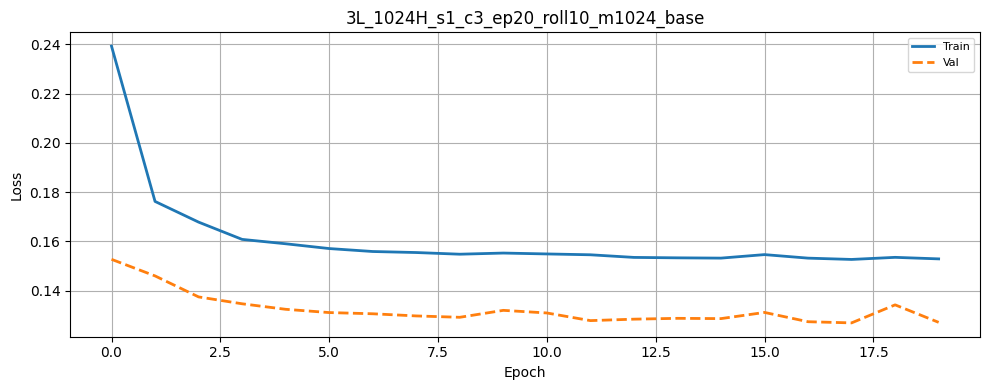

In [111]:
import matplotlib.pyplot as plt

num_conditions = len(results)

fig, axes = plt.subplots(
    nrows=num_conditions,
    ncols=1,
    figsize=(10, 4 * num_conditions),
    sharex=True
)

# 조건이 1개일 때 axes가 list가 아니라 단일 객체가 되는 것 방지
if num_conditions == 1:
    axes = [axes]

for ax, (setting_name, result) in zip(axes, results.items()):
    ax.plot(result['train_loss'], label="Train", linewidth=2)
    ax.plot(result['val_loss'], linestyle='--', label="Val", linewidth=2)

    ax.set_title(setting_name)
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()


In [112]:
import os
import csv

# ==================================================
# CSV save path
# ==================================================
save_dir = "/home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_shift"
os.makedirs(save_dir, exist_ok=True)

csv_path = os.path.join(save_dir, "loss_curves_3L_1024H_s1_c3_shift.csv")

# ==================================================
# Write CSV
# ==================================================
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "setting_name",
            "epoch",
            "train_total_loss",
            "val_total_loss",
            "train_tracking_loss",
            "val_tracking_loss",
            "train_smooth_loss",
            "val_smooth_loss",
            "train_constraint_loss",
            "val_constraint_loss",
        ]
    )
    writer.writeheader()

    for setting_name, result in results.items():
        num_epoch = len(result["train_loss"])

        for epoch in range(num_epoch):
            writer.writerow({
                "setting_name": setting_name,
                "epoch": epoch + 1,
                "train_total_loss": result["train_loss"][epoch],
                "val_total_loss": result["val_loss"][epoch],
                "train_tracking_loss": result["train_tracking_loss"][epoch],
                "val_tracking_loss": result["val_tracking_loss"][epoch],
                "train_smooth_loss": result["train_smooth_loss"][epoch],
                "val_smooth_loss": result["val_smooth_loss"][epoch],
                "train_constraint_loss": result["train_constraint_loss"][epoch],
                "val_constraint_loss": result["val_constraint_loss"][epoch],
            })

print(f"[CSV] Saved loss curves to: {csv_path}")


[CSV] Saved loss curves to: /home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_shift/loss_curves_3L_1024H_s1_c3_shift.csv
